## Comparison by difficulty

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "/Data/allegra-maria-pia.boustany/llm_cross_eval/results/exp1_turn1_Qwen3-4B-Thinking-2507_vs_Qwen3-30B-A3B-Thinking-2507_1768301480.csv"
df = pd.read_csv(csv_path)

# safe log transform
df["ratio"] = df["ratio_pA_over_pB"].clip(lower=1e-30)
df["log10_ratio"] = np.log10(df["ratio"])
df["abs_log10_ratio"] = df["log10_ratio"].abs()

df.head()


,seed,example_id,bucket,level,prompt,continuation_text,token_idx,token_id,token_str,p_a,p_b,ratio_pA_over_pB,ratio,log10_ratio,abs_log10_ratio
0,42,test_3927,easy,1,Solve the following math problem. Show your wo...,To find the smallest multiple of 6 that is gre...,0,1249,To,0.917652,0.862054,1.064494,1.064494,0.027143,0.027143
1,42,test_3927,easy,1,Solve the following math problem. Show your wo...,To find the smallest multiple of 6 that is gre...,1,1477,find,0.939413,0.861212,1.090803,1.090803,0.037746,0.037746
2,42,test_3927,easy,1,Solve the following math problem. Show your wo...,To find the smallest multiple of 6 that is gre...,2,279,the,0.997105,0.999594,0.997510,0.997510,-0.001083,0.001083
3,42,test_3927,easy,1,Solve the following math problem. Show your wo...,To find the smallest multiple of 6 that is gre...,3,24632,smallest,0.999898,0.991068,1.008910,1.008910,0.003852,0.003852
4,42,test_3927,easy,1,Solve the following math problem. Show your wo...,To find the smallest multiple of 6 that is gre...,4,5248,multiple,0.999989,0.999969,1.000020,1.000020,0.000009,0.000009


In [4]:
group_cols = ["seed", "example_id", "bucket", "level"]

per_problem = df.groupby(group_cols).agg(
    n_tokens=("token_idx", "count"),
    mean_abs_log10=("abs_log10_ratio", "mean"),
    p95_abs_log10=("abs_log10_ratio", lambda x: np.percentile(x, 95)),
    max_abs_log10=("abs_log10_ratio", "max"),
).reset_index()

per_problem.sort_values(["bucket","level","p95_abs_log10"], ascending=[True, True, False]).head(15)


,seed,example_id,bucket,level,n_tokens,mean_abs_log10,p95_abs_log10,max_abs_log10
0,42,test_105,easy,1,500,0.111936,0.624956,1.713427
11,42,test_466,easy,1,500,0.106008,0.587400,4.003652
8,42,test_3927,easy,1,500,0.091209,0.454822,2.341119
9,42,test_4371,easy,2,500,0.110162,0.665586,3.657574
3,42,test_1542,easy,2,500,0.074562,0.401553,1.621818
2,42,test_1416,easy,2,500,0.060625,0.373858,1.560746
6,42,test_267,hard,5,500,0.079819,0.471786,2.731305
7,42,test_3110,hard,5,500,0.068860,0.422207,3.196136
5,42,test_257,hard,5,500,0.071171,0.357614,3.945973
14,42,test_933,medium,3,500,0.173142,0.814504,5.444797


/tmp/ipykernel_2325789/3875310396.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order)


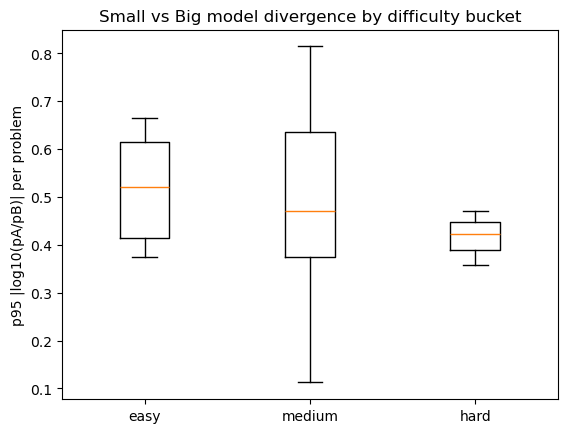

In [5]:
order = ["easy", "medium", "hard"]
data = [per_problem.loc[per_problem["bucket"]==b, "p95_abs_log10"].values for b in order]

plt.figure()
plt.boxplot(data, labels=order)
plt.ylabel("p95 |log10(pA/pB)| per problem")
plt.title("Small vs Big model divergence by difficulty bucket")
plt.show()
